In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14,6)


d:\Document\STUDY\HK11\KLTN\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
# ==============================
# CELL 2: LOAD DATA
# ==============================

ohlc = pd.read_csv("data/ohlc.csv", parse_dates=["date"])
fundamental = pd.read_csv("data/fundamental.csv")
news = pd.read_csv("data/news.csv", parse_dates=["date"])

ohlc = ohlc.sort_values(["mack","date"])
fundamental = fundamental.sort_values(["mack","nam","quy"])
news = news.sort_values(["mack","date"])

print(ohlc.shape, fundamental.shape, news.shape)


(144176, 7) (2265, 11) (35481, 5)


In [20]:
# TECHNICAL INDICATORS
# SMA, EMA
def add_ma(df):
    df["sma_10"] = df["close"].rolling(10).mean()
    df["sma_20"] = df["close"].rolling(20).mean()
    df["ema_10"] = df["close"].ewm(span=10, adjust=False).mean()
    df["ema_20"] = df["close"].ewm(span=20, adjust=False).mean()
    return df

ohlc = ohlc.groupby("mack", group_keys=False).apply(add_ma)

# RSI
def compute_rsi(x, window=14):
    delta = x.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    rs = gain.rolling(window).mean() / loss.rolling(window).mean()
    return 100 - (100 / (1 + rs))

ohlc["rsi_14"] = ohlc.groupby("mack")["close"].transform(compute_rsi)

ohlc["return"] = ohlc.groupby("mack")["close"].pct_change()

ohlc["macd"] = (
    ohlc.groupby("mack")["close"]
    .transform(lambda x: x.ewm(span=12, adjust=False).mean()
               - x.ewm(span=26, adjust=False).mean())
)

ohlc["macd_signal"] = ohlc.groupby("mack")["macd"].transform(
    lambda x: x.ewm(span=9, adjust=False).mean()
)

ohlc["volatility_20"] = (
    ohlc.groupby("mack")["return"]
    .transform(lambda x: x.rolling(20).std())
)

# MACD & Volatility
ohlc["return"] = ohlc.groupby("mack")["close"].pct_change()

ohlc["macd"] = (
    ohlc.groupby("mack")["close"]
    .transform(lambda x: x.ewm(span=12, adjust=False).mean()
               - x.ewm(span=26, adjust=False).mean())
)

ohlc["macd_signal"] = ohlc.groupby("mack")["macd"].transform(
    lambda x: x.ewm(span=9, adjust=False).mean()
)

ohlc["volatility_20"] = (
    ohlc.groupby("mack")["return"]
    .transform(lambda x: x.rolling(20).std())
)


In [21]:
# FUNDAMENTAL → DAILY
def quarter_to_date(y, q):
    return pd.Timestamp(y, q*3, 1) + pd.offsets.MonthEnd(0)

fundamental["date"] = fundamental.apply(
    lambda x: quarter_to_date(x["nam"], x["quy"]), axis=1
)

fundamental_features = [
    "eps","roe","roa","pb","pe",
    "lnst_yoy","nophaitra_vcsh","vonhoa_tts"
]

daily_fundamental = []

for mack, g in fundamental.groupby("mack"):
    g = g.set_index("date")[fundamental_features]
    g = g.resample("D").ffill()
    g["mack"] = mack
    daily_fundamental.append(g.reset_index())

fundamental_daily = pd.concat(daily_fundamental, ignore_index=True)


In [22]:
#NEWS SENTIMENT – PHOBERT
# ==============================
# CELL BS1: CUDA & PHOBERT
# ==============================

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

model = AutoModelForSequenceClassification.from_pretrained(
    "wonrax/phobert-base-vietnamese-sentiment"
)

model = model.to(device)
model.eval()

print("✓ PhoBERT loaded successfully")



Using device: cpu
✓ PhoBERT loaded successfully


In [23]:
# ==============================
# CELL BS2: PREPARE TEXT
# ==============================

news["text"] = news["title"].fillna(news["title"]).astype(str)

news["text"] = news["text"].str.replace("\n", " ").str.strip()

news = news.reset_index(drop=True)

news[["date","mack","text"]].head()


,date,mack,text
0,2020-01-19,ACB,ACB có thể chọn đối tác độc quyền bancassuranc...
1,2020-01-22,ACB,ACB: Báo cáo quản trị công ty năm 2019
2,2020-02-10,ACB,ACB sẽ họp ĐHĐCĐ thường niên vào ngày 7/4
3,2020-02-10,ACB,ACB: Ngày ĐKCC để thực hiện quyền tham dự họp ...
4,2020-02-19,ACB,"ACB: 5.3.2020, ngày GDKHQ tham dự Đại hội đồng..."


In [24]:
@torch.no_grad()
def batch_phobert_sentiment(texts, batch_size=32, max_length=256):
    """
    Input:
        texts: list[str]
    Output:
        probs: np.ndarray shape (batch, 3)
               [pos, neu, neg]
    """

    encodings = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    encodings = {k: v.to(device) for k, v in encodings.items()}

    outputs = model(**encodings)
    logits = outputs.logits                     # (batch, 3)
    probs = F.softmax(logits, dim=1)            # softmax

    return probs.cpu().numpy()


In [25]:
# ==============================
# CELL BS4: APPLY SENTIMENT (BATCH + CUDA + PROGRESS)
# ==============================

import numpy as np
from tqdm import tqdm

# ------------------------------
# CONFIG
# ------------------------------
BATCH_SIZE = 32        # RTX 3060 trở lên có thể dùng 64
TEXT_COL = "text"      # cột chứa nội dung news

texts = news[TEXT_COL].astype(str).tolist()
n = len(texts)

all_probs = []

# ------------------------------
# BATCH INFERENCE
# ------------------------------
for i in tqdm(range(0, n, BATCH_SIZE), desc="PhoBERT Sentiment (GPU)"):
    batch_texts = texts[i:i + BATCH_SIZE]

    probs = batch_phobert_sentiment(
        batch_texts,
        batch_size=len(batch_texts)
    )  # shape: (batch, 3)

    all_probs.append(probs)

# ------------------------------
# STACK RESULTS
# ------------------------------
all_probs = np.vstack(all_probs)

news["sent_pos"] = all_probs[:, 0]
news["sent_neu"] = all_probs[:, 1]
news["sent_neg"] = all_probs[:, 2]

# sentiment score (liên tục)
news["sent_score"] = news["sent_pos"] - news["sent_neg"]

# ------------------------------
# MAP TO {-1, 0, 1}
# ------------------------------
# argmax: 0=pos, 1=neu, 2=neg
sent_label_idx = np.argmax(all_probs, axis=1)

news["sentiment_label"] = np.select(
    [
        sent_label_idx == 0,
        sent_label_idx == 1,
        sent_label_idx == 2
    ],
    [
        1,   # positive
        0,   # neutral
       -1    # negative
    ]
)

news[[
    "sent_pos",
    "sent_neu",
    "sent_neg",
    "sent_score",
    "sentiment_label"
]].head()


PhoBERT Sentiment (GPU): 100%|██████████| 1109/1109 [23:27<00:00,  1.27s/it]


,sent_pos,sent_neu,sent_neg,sent_score,sentiment_label
0,0.017105,0.901090,0.081804,-0.064699,0
1,0.060153,0.071302,0.868545,-0.808393,-1
2,0.040455,0.122901,0.836644,-0.796189,-1
3,0.054682,0.549412,0.395905,-0.341223,0
4,0.012391,0.870947,0.116662,-0.104272,0


In [26]:
sent_daily = (
    news.groupby(["mack","date"])
    .agg({
        "sent_pos":"mean",
        "sent_neu":"mean",
        "sent_neg":"mean",
        "sent_score":"mean"
    }).reset_index()
)


In [27]:
# ==============================
# MERGE FULL DATASET
# ==============================

df = (
    ohlc
    .merge(fundamental_daily, on=["mack", "date"], how="left")
    .merge(sent_daily, on=["mack", "date"], how="left")
)

df = df.sort_values(["mack", "date"]).reset_index(drop=True)

print("Merged shape:", df.shape)
df.head()

Merged shape: (144176, 28)


,date,mack,open,high,low,close,volume,sma_10,sma_20,ema_10,...,roa,pb,pe,lnst_yoy,nophaitra_vcsh,vonhoa_tts,sent_pos,sent_neu,sent_neg,sent_score
0,2020-01-02,ACB,6580.0,6640.0,6560.0,6640.0,1163109,NaN,NaN,6640.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-03,ACB,6640.0,6690.0,6600.0,6640.0,1055528,NaN,NaN,6640.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-06,ACB,6640.0,6640.0,6500.0,6500.0,1286035,NaN,NaN,6614.545455,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-07,ACB,6500.0,6560.0,6500.0,6500.0,1050934,NaN,NaN,6593.719008,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-08,ACB,6500.0,6500.0,6350.0,6380.0,2304937,NaN,NaN,6554.861007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# ==============================
# SAFE FORWARD FILL (NO INDEX ERROR)
# ==============================

fund_cols = [
    "eps","roe","roa","pb","pe",
    "lnst_yoy","nophaitra_vcsh","vonhoa_tts"
]

sent_cols = ["sent_score"]

# Fundamental: forward fill theo mã
df[fund_cols] = (
    df.groupby("mack")[fund_cols]
      .transform(lambda x: x.ffill())
)

# Sentiment: forward fill tối đa 5 ngày (TRÁNH LEAKAGE)
df[sent_cols] = (
    df.groupby("mack")[sent_cols]
      .transform(lambda x: x.ffill(limit=5))
)

print("✓ Forward fill completed safely")


✓ Forward fill completed safely


In [29]:
df = df.dropna().reset_index(drop=True)
print("Final shape:", df.shape)
df.head()


Final shape: (22456, 28)


,date,mack,open,high,low,close,volume,sma_10,sma_20,ema_10,...,roa,pb,pe,lnst_yoy,nophaitra_vcsh,vonhoa_tts,sent_pos,sent_neu,sent_neg,sent_score
0,2020-04-03,ACB,5220.0,5600.0,5220.0,5510.0,3574343,5595.0,6039.0,5618.389488,...,0.003988,1.04327,19.2555,0.125313,12.171197,0.076399,0.012418,0.941172,0.046411,-0.033993
1,2020-04-10,ACB,5480.0,5830.0,5480.0,5720.0,2517477,5607.0,5787.5,5735.437848,...,0.003988,1.04327,19.2555,0.125313,12.171197,0.076399,0.279774,0.068717,0.651509,-0.371735
2,2020-04-14,ACB,5770.0,5830.0,5680.0,5770.0,3167293,5668.0,5745.5,5746.863353,...,0.003988,1.04327,19.2555,0.125313,12.171197,0.076399,0.021751,0.191405,0.786843,-0.765092
3,2020-04-22,ACB,5720.0,5890.0,5600.0,5890.0,2637424,5840.0,5729.0,5845.434206,...,0.003988,1.04327,19.2555,0.125313,12.171197,0.076399,0.014501,0.565609,0.419889,-0.405388
4,2020-04-23,ACB,5920.0,6000.0,5860.0,5860.0,2076603,5849.0,5726.0,5848.082532,...,0.003988,1.04327,19.2555,0.125313,12.171197,0.076399,0.016153,0.674133,0.309714,-0.293560


In [30]:
# TARGET (T+1 return)
df["target"] = (df.groupby("mack")["return"].shift(-1) > 0).astype(int)
df = df.dropna()


In [31]:
# ==============================
# SECTOR MAPPING (11 NGÀNH)
# ==============================

sector_map = {
    # 1. Dầu khí
    "HPG":"Dầu khí","HSG":"Dầu khí","NKG":"Dầu khí","PVT":"Dầu khí","PVD":"Dầu khí",

    # 2. Nguyên vật liệu
    "GVR":"Nguyên vật liệu","PHR":"Nguyên vật liệu","DGC":"Nguyên vật liệu",
    "DCM":"Nguyên vật liệu","DPM":"Nguyên vật liệu","BMP":"Nguyên vật liệu",
    "VGC":"Nguyên vật liệu","HT1":"Nguyên vật liệu",

    # 3. Công nghiệp
    "GEE":"Công nghiệp","GEX":"Công nghiệp","HDG":"Công nghiệp","PC1":"Công nghiệp",
    "REE":"Công nghiệp","MSN":"Công nghiệp","VIC":"Công nghiệp","GMD":"Công nghiệp",
    "VSC":"Công nghiệp","SCS":"Công nghiệp","VJC":"Công nghiệp","VCG":"Công nghiệp",
    "CII":"Công nghiệp","HHV":"Công nghiệp","PTB":"Công nghiệp","CTD":"Công nghiệp",
    "VTP":"Công nghiệp",

    # 4. Hàng tiêu dùng
    "TLG":"Hàng tiêu dùng","VNM":"Hàng tiêu dùng","HAG":"Hàng tiêu dùng",
    "SBT":"Hàng tiêu dùng","KDC":"Hàng tiêu dùng","VHC":"Hàng tiêu dùng",
    "DBC":"Hàng tiêu dùng","ANV":"Hàng tiêu dùng","PAN":"Hàng tiêu dùng",
    "SAB":"Hàng tiêu dùng","PNJ":"Hàng tiêu dùng",

    # 5. Dược phẩm & Y tế
    "IMP":"Dược phẩm và Y tế",

    # 6. Dịch vụ tiêu dùng
    "MWG":"Dịch vụ Tiêu dùng","FRT":"Dịch vụ Tiêu dùng","PLX":"Dịch vụ Tiêu dùng",
    "TCH":"Dịch vụ Tiêu dùng","DGW":"Dịch vụ Tiêu dùng",

    # 7. Viễn thông
    "CTR":"Viễn thông",

    # 8. Tiện ích cộng đồng
    "POW":"Tiện ích cộng đồng","NT2":"Tiện ích cộng đồng",
    "PPC":"Tiện ích cộng đồng","GAS":"Tiện ích cộng đồng","BWE":"Tiện ích cộng đồng",

    # 9. Tài chính
    "HDC":"Tài chính","VHM":"Tài chính","VRE":"Tài chính","BCM":"Tài chính",
    "KDH":"Tài chính","KBC":"Tài chính","DXG":"Tài chính","PDR":"Tài chính",
    "VPI":"Tài chính","SJS":"Tài chính","NLG":"Tài chính","DIG":"Tài chính",
    "SIP":"Tài chính","KOS":"Tài chính","DXS":"Tài chính","SZC":"Tài chính",
    "SSI":"Tài chính","VIX":"Tài chính","VND":"Tài chính","VCI":"Tài chính",
    "HCM":"Tài chính","FTS":"Tài chính","BSI":"Tài chính","DSE":"Tài chính",
    "CTS":"Tài chính","BVH":"Tài chính","EVF":"Tài chính",

    # 10. Ngân hàng
    "VCB":"Ngân hàng","CTG":"Ngân hàng","BID":"Ngân hàng","TCB":"Ngân hàng",
    "VPB":"Ngân hàng","MBB":"Ngân hàng","HDB":"Ngân hàng","LPB":"Ngân hàng",
    "ACB":"Ngân hàng","STB":"Ngân hàng","SHB":"Ngân hàng","VIB":"Ngân hàng",
    "SSB":"Ngân hàng","TPB":"Ngân hàng","EIB":"Ngân hàng","MSB":"Ngân hàng",
    "OCB":"Ngân hàng","NAB":"Ngân hàng",

    # 11. Công nghệ thông tin
    "FPT":"Công nghệ thông tin","CMG":"Công nghệ thông tin"
}


In [32]:
# ==============================
# GÁN NGÀNH VÀ KIỂM TRA DỮ LIỆU
# ==============================

df["sector"] = df["mack"].map(sector_map)

# Check missing
missing = df[df["sector"].isna()]["mack"].unique()
print("Missing sector tickers:", missing)

# Preview
df[["mack","sector"]].drop_duplicates().sort_values("sector").head(20)


Missing sector tickers: []


,mack,sector
22243,VTP,Công nghiệp
10773,MSN,Công nghiệp
21905,VSC,Công nghiệp
13859,PTB,Công nghiệp
14527,REE,Công nghiệp
7882,HHV,Công nghiệp
7606,HDG,Công nghiệp
6415,GMD,Công nghiệp
6078,GEX,Công nghiệp
15068,SCS,Công nghiệp


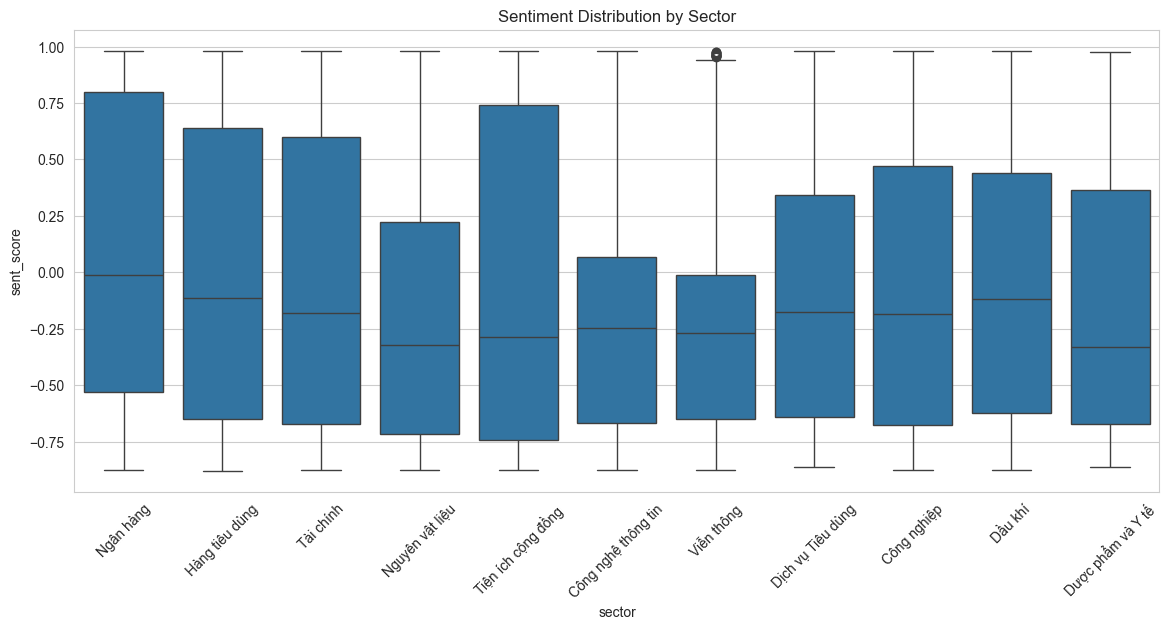

In [33]:
# SENTIMENT × NGÀNH
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x="sector", y="sent_score")
plt.xticks(rotation=45)
plt.title("Sentiment Distribution by Sector")
plt.show()


In [34]:
# FEATURE SET
technical_features = [
    "sma_10","sma_20","ema_10","ema_20",
    "rsi_14","macd","macd_signal",
    "volatility_20"
]

sentiment_features = ["sent_pos","sent_neu","sent_neg","sent_score"]

X_features = technical_features + fundamental_features + sentiment_features

X = df[X_features]
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [35]:
# TRAIN / TEST (TIME SERIES)
split_date = "2023-01-01"
train_idx = df["date"] < split_date

X_train, X_test = X_scaled[train_idx], X_scaled[~train_idx]
y_train, y_test = y[train_idx], y[~train_idx]


In [36]:
# TRAIN MLP (XÁC SUẤT)
mlp = MLPClassifier(
    hidden_layer_sizes=(128,64),
    max_iter=600,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
y_prob = mlp.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.5033640226628895
              precision    recall  f1-score   support

           0       0.52      0.64      0.57      5859
           1       0.48      0.36      0.41      5437

    accuracy                           0.50     11296
   macro avg       0.50      0.50      0.49     11296
weighted avg       0.50      0.50      0.49     11296



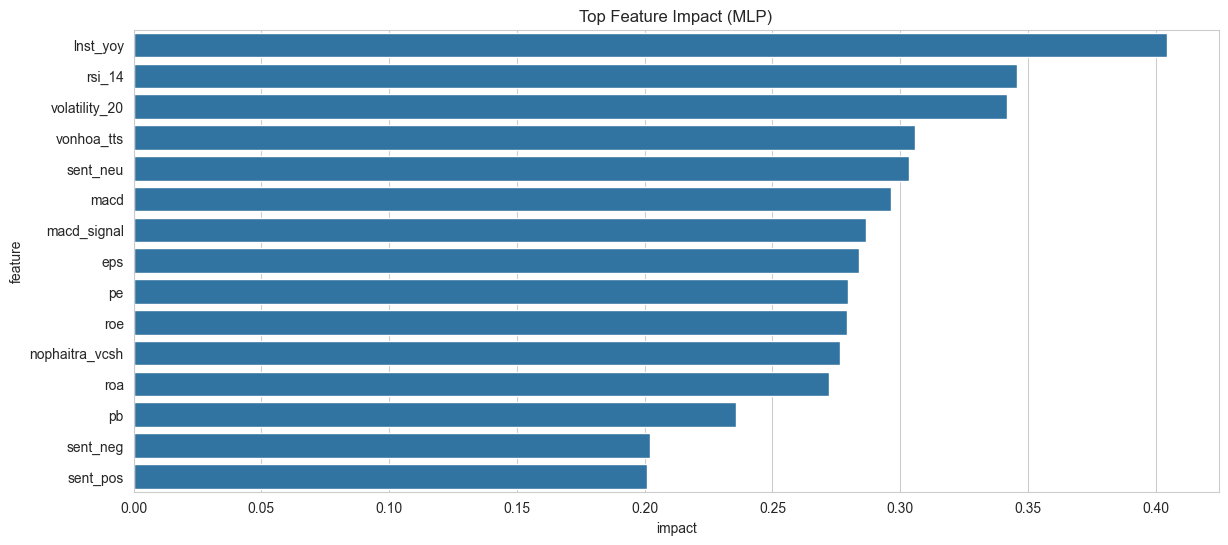

In [37]:
# FEATURE IMPACT
impact = np.abs(mlp.coefs_[0]).mean(axis=1)

impact_df = pd.DataFrame({
    "feature": X_features,
    "impact": impact
}).sort_values("impact", ascending=False)

sns.barplot(data=impact_df.head(15), x="impact", y="feature")
plt.title("Top Feature Impact (MLP)")
plt.show()


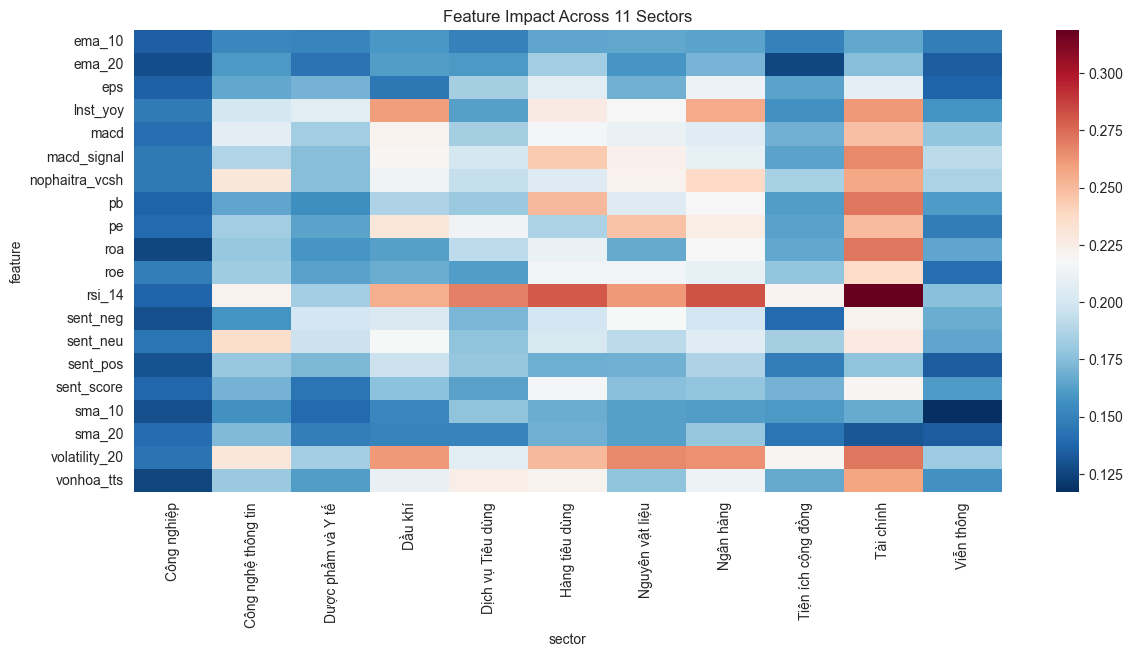

In [38]:
# TÁC ĐỘNG BIẾN × NGÀNH
sector_impact = []

for sector, g in df.groupby("sector"):
    Xs = scaler.fit_transform(g[X_features])
    ys = g["target"]
    model = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300)
    model.fit(Xs, ys)
    w = np.abs(model.coefs_[0]).mean(axis=1)
    sector_impact.append(pd.DataFrame({
        "sector": sector,
        "feature": X_features,
        "impact": w
    }))

sector_impact_df = pd.concat(sector_impact)

pivot = sector_impact_df.pivot(
    index="feature", columns="sector", values="impact"
)

sns.heatmap(pivot, cmap="RdBu_r")
plt.title("Feature Impact Across 11 Sectors")
plt.show()


In [39]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42


In [40]:
# ==============================
# TARGET: PRICE UP / DOWN
# ==============================

df["return_1d"] = df.groupby("mack")["close"].pct_change().shift(-1)
df["target"] = np.where(
    df["return_1d"] > 0.005, 1,
    np.where(df["return_1d"] < -0.005, 0, np.nan)
)
df = df.dropna(subset=["target"])



In [41]:
# ==============================
# FEATURE GROUPS
# ==============================

fundamental_features = [
    "pe","pb","roe","roa","eps","lnst_yoy",
    "vonhoa_tts","nophaitra_vcsh"
]

technical_features = [
    "rsi","macd","macd_signal","macd_hist",
    "sma_20","sma_50","ema_20",
    "volatility_20","volume_ratio"
]

sentiment_features = [
    "sent_score","sent_pos","sent_neg"
]

feature_groups = {
    "Model 1 | Fundamental": fundamental_features,
    "Model 2 | Technical": technical_features,
    "Model 3 | Sentiment": sentiment_features,
    "Model 4 | Fund + Tech": fundamental_features + technical_features,
    "Model 5 | Fund + Sent": fundamental_features + sentiment_features,
    "Model 6 | Tech + Sent": technical_features + sentiment_features,
    "Model 7 | All": fundamental_features + technical_features + sentiment_features
}


In [56]:
# ==============================
# CREATE SMOOTH TARGET (5-DAY RETURN)
# ==============================

df = df.sort_values(["mack", "date"])

# future 5-day return
df["ret_5"] = (
    df.groupby("mack")["close"]
    .pct_change(5)
    .shift(-5)
)

# remove noisy middle zone (40% - 60%)
q_low = df["ret_5"].quantile(0.4)
q_high = df["ret_5"].quantile(0.6)

df = df[(df["ret_5"] <= q_low) | (df["ret_5"] >= q_high)]

# binary target
df["target"] = (df["ret_5"] > 0).astype(int)


In [57]:
# ==============================
# RUN EXPERIMENT: SECTOR × MODEL
# ==============================

results = []

for sector in sorted(df["sector"].unique()):
    df_sector = df[df["sector"] == sector].copy()

    # tránh ngành quá ít dữ liệu
    if len(df_sector) < 150:
        continue

    for model_name, features in feature_groups.items():

        # chỉ lấy feature tồn tại
        available_features = [f for f in features if f in df_sector.columns]

        if len(available_features) < 3:
            continue

        X = df_sector[available_features]
        y = df_sector["target"]

        # drop NaN
        mask = X.notna().all(axis=1)
        X, y = X[mask], y[mask]

        # cần đủ 2 lớp
        if y.nunique() < 2:
            continue

        metrics = train_mlp(X, y)

        results.append({
            "Sector": sector,
            "Model": model_name,
            "Accuracy": metrics["Accuracy"],
            "AUC": metrics["AUC"],
            "n_obs": len(y)
        })

results_df = pd.DataFrame(results)
results_df


,Sector,Model,Accuracy,AUC,n_obs
0,Công nghiệp,Model 1 | Fundamental,0.473373,0.551916,841
1,Công nghiệp,Model 2 | Technical,0.550296,0.600310,841
2,Công nghiệp,Model 3 | Sentiment,0.473373,0.530361,841
3,Công nghiệp,Model 4 | Fund + Tech,0.479290,0.521414,841
4,Công nghiệp,Model 5 | Fund + Sent,0.520710,0.531558,841
5,Công nghiệp,Model 6 | Tech + Sent,0.573964,0.577628,841
6,Công nghiệp,Model 7 | All,0.473373,0.516765,841
7,Dầu khí,Model 1 | Fundamental,0.687500,0.724311,396
8,Dầu khí,Model 2 | Technical,0.650000,0.733709,396
9,Dầu khí,Model 3 | Sentiment,0.462500,0.449875,396


In [58]:
# ==============================
# AUC TABLE
# ==============================

auc_table = results_df.pivot(
    index="Sector",
    columns="Model",
    values="AUC"
)

auc_table.round(3)


Model,Model 1 | Fundamental,Model 2 | Technical,Model 3 | Sentiment,Model 4 | Fund + Tech,Model 5 | Fund + Sent,Model 6 | Tech + Sent,Model 7 | All
Sector,,,,,,,
Công nghiệp,0.552,0.600,0.530,0.521,0.532,0.578,0.517
Dầu khí,0.724,0.734,0.450,0.791,0.613,0.757,0.773
Dịch vụ Tiêu dùng,0.636,0.554,0.470,0.471,0.534,0.491,0.480
Hàng tiêu dùng,0.763,0.606,0.431,0.706,0.668,0.590,0.664
Nguyên vật liệu,0.462,0.555,0.491,0.443,0.512,0.522,0.605
Ngân hàng,0.639,0.586,0.559,0.668,0.644,0.572,0.651
Tiện ích cộng đồng,0.517,0.575,0.459,0.454,0.488,0.362,0.575
Tài chính,0.524,0.719,0.517,0.555,0.558,0.664,0.600


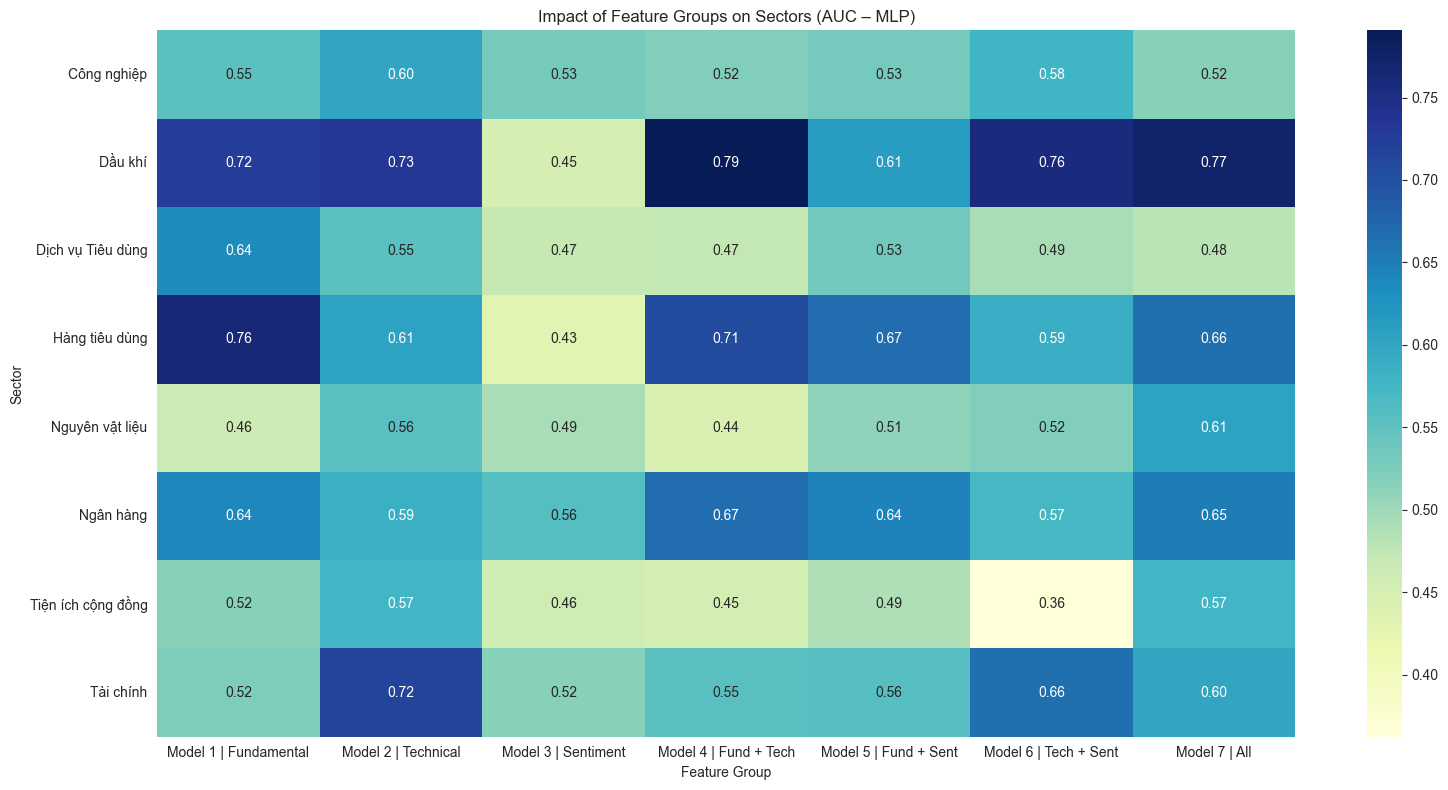

In [59]:
# ==============================
# HEATMAP AUC
# ==============================

plt.figure(figsize=(16,8))
sns.heatmap(
    auc_table,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)
plt.title("Impact of Feature Groups on Sectors (AUC – MLP)")
plt.xlabel("Feature Group")
plt.ylabel("Sector")
plt.tight_layout()
plt.show()


In [ ]:
# # 3. TARGET CONSTRUCTION
# # =====================


# df = df.sort_values(["mack", "date"]).copy()


# # Future 5-day return
# df["ret_5"] = (
#     df.groupby("mack")["close"]
#         .pct_change(5)
#         .shift(-5)
# )


# # remove noisy middle zone
# q_low = df["ret_5"].quantile(0.4)
# q_high = df["ret_5"].quantile(0.6)


# df = df[(df["ret_5"] <= q_low) | (df["ret_5"] >= q_high)]


# # binary target
# df["target"] = (df["ret_5"] > 0).astype(int)


# print("After target filter:", df.shape)